<a href="https://colab.research.google.com/github/marco11235813/Retencion-de-clientes---NoCountry/blob/main/EDA_NC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Retención de clientes
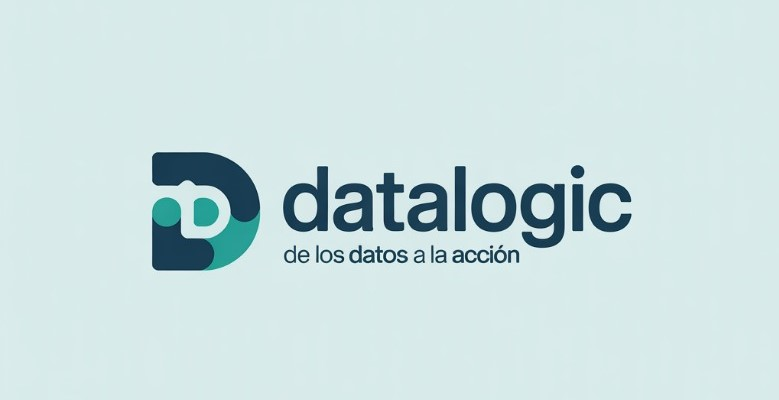


#Importación y carga
###Se importan las bibliotecas:
  - Pandas: Manipulación y visualización de los datos
  - Numpy: Generar Arrays
  - Mathplot: Para generar gráficos
  - Seaborn: Para generar y estilizar gráficos
  - Scipy: Para realizar cálculos

###Carga de datos:
Desde BigQuery se importa el dataset

###Copia:
Se creará una copia de los datos para manipularlos y trabajar preservando la integridad del df original

In [ ]:
#Carga de librerias
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
#Cargo el dataset desde bigQuery
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

from google.cloud import bigquery
client= bigquery.Client(project = 'even-antenna-473123-d3')

query = '''SELECT *
FROM `even-antenna-473123-d3.customer_churn.customer_data`'''
df = client.query(query).to_dataframe()

In [ ]:
#Creo una copia del dataframe denominada df_churn
df_churn = df.copy()

#Exploración del dataframe

In [ ]:
"""Muestro la información del dataset: La cantidad de entradas, columnas y sus
respectivos nombres, registros no nulos por columa y el tipo de dato.
Además se visualizan los primeros y últimos 5 registros del dataset"""
display(df_churn.info(), df_churn.head(), df_churn.tail())

##Exploración numérica


In [ ]:
#Descripción estadística
df_churn.describe()

In [ ]:
#Cuartiles, rango IQ y valores max y min de las columnas numéricas
num = df_churn.select_dtypes(include=['float64', 'int64'])
for col in num.columns:
    print(f"Columna: {col}")
    print(f"Cuartiles: {num[col].quantile([0.25, 0.5, 0.75])}")
    print(f"Rango intercuartil (IQR): {num[col].quantile(0.75) - num[col].quantile(0.25)}")
    print(f"Valor máximo: {num[col].max()}")
    print(f"Valor mínimo: {num[col].min()}")
    print("\n")


In [ ]:
#Boxplot interactivo de las columnas numéricas
fig = px.box(df_churn, x=num.columns, title='Boxplot de las columnas numéricas', color_discrete_sequence=['blue'])
fig.update_layout(xaxis_title='Columnas', yaxis_title='Valores', showlegend=True)
fig.show()

In [ ]:
#Histograma de cada columna numérica
df_churn.hist(figsize=(20,15), bins=50, xlabelsize=8, ylabelsize=8, grid=False, color='blue')
plt.show()

##Exploración categórica

In [ ]:
#Muestro los valores únicos de cada categoría
display(
    df_churn['gender'].unique(),
    df_churn['region_category'].unique(),
    df_churn['membership_category'].unique(),
    df_churn['joined_through_referral'].unique(),
    df_churn['preferred_offer_types'].unique(),
    df_churn['medium_of_operation'].unique(),
    df_churn['internet_option'].unique(),
    df_churn['used_special_discount'].unique(),
    df_churn['offer_application_preference'].unique(),
    df_churn['past_complaint'].unique(),
    df_churn['complaint_status'].unique(),
    df_churn['feedback'].unique()
)


In [ ]:
#Mostrar cantidad de valores pertenecientes a las categorías de una columna
display(
    df_churn['gender'].value_counts(),
    df_churn['region_category'].value_counts(),
    df_churn['membership_category'].value_counts(),
    df_churn['joined_through_referral'].value_counts(),
    df_churn['preferred_offer_types'].value_counts(),
    df_churn['medium_of_operation'].value_counts(),
    df_churn['internet_option'].value_counts(),
    df_churn['used_special_discount'].value_counts(),
    df_churn['offer_application_preference'].value_counts(),
    df_churn['past_complaint'].value_counts(),
    df_churn['complaint_status'].value_counts,
    df_churn['feedback'].value_counts(),
)

## Exploración de identificadores de usuarios

La columna security_no será tomada como id único para cada usuario de la fintech

In [ ]:
#Exploración de duplicados por número de seguridad social
display(df_churn.duplicated(subset='security_no').sum())

#Análisis

##Gráficos

In [ ]:
#Total de usuarios por género, región y edad (En segmentos de 10 años)
bins = [18, 25, 40, 55, 70, 100]  # límites de los intervalos
labels = ['18-25', '26-40', '41-55', '56-70', '71-100']  # etiquetas para los intervalos

#Agrupo las edades
df_churn['age_group'] = pd.cut(df_churn['age'], bins=bins, labels=labels, right=True, include_lowest=True)

#Agrupo por genero, región y edad
user_age_gender = df_churn.groupby(['gender', 'region_category', 'age_group']).size().reset_index(name='count')

#Imprimo resultados
print("Total de usuarios por género, región y edad categorizada: ")
print(user_age_gender)

In [ ]:
#Grafico usuarios por edad y región agrupados en segmentos de 10 años
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='count', hue='region_category', data=user_age_gender, palette='coolwarm' , errorbar=None, edgecolor='black', linewidth=1, alpha=0.7)
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Usuarios por edad y región')
plt.xticks(rotation=45)
plt.legend(title='Región', loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
#Usuarios genero y edad
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='count', hue='gender', data=user_age_gender, palette='coolwarm', errorbar=None, edgecolor='black', linewidth=1, alpha=0.7)
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Usuarios por edad y género')
plt.xticks(rotation=45)
plt.legend(title='Género', loc='upper right')
plt.tight_layout()
plt.show()


In [ ]:
#Tipo de ofertas preferidas, medios de operación e internet y tipo de membresias agrupados por región
offer_medium_internet=df_churn.groupby(['region_category', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'membership_category']).size().reset_index(name='count')
print("Tipo de ofertas preferidas, medios de operación e internet y tipo de membresias agrupados por región: ")
print(offer_medium_internet)

In [ ]:
#Membresias por region
plt.figure(figsize=(10, 6))
sns.barplot(x='region_category', y='count', hue='membership_category', data=offer_medium_internet, palette='coolwarm', errorbar=None, edgecolor='black', linewidth=1, alpha=0.7)
plt.xlabel('Región')
plt.ylabel('Cantidad de usuarios')
plt.title('Usuarios por región y tipo de membresía')
plt.xticks(rotation=45)
plt.legend(title='Tipo de membresía', loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
#Grupo etario por medio de operacion
age_medium_operation=df_churn.groupby(['age_group', 'medium_of_operation']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='count', hue='medium_of_operation', data=age_medium_operation, palette='coolwarm', errorbar=None, edgecolor='black', linewidth=1, alpha=0.7)
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Usuarios por edad y medio de operación')
plt.xticks(rotation=45)
plt.legend(title='Medio de operación', loc='upper right')
plt.tight_layout()
plt.show()



In [ ]:
#Se agruparán registros por id
df_agrupado = df_churn.groupby('security_no').agg({
    'joining_date': 'first', #Seleccióna la primer fecha que aparezca de registro
    'membership_category': 'first', #Selecciona la primer categoria de registro de un usuario
    'days_since_last_login': 'max', #El número de días desde la última visita
    'avg_time_spent': 'sum', #Suma los promedios de tiempo que pasa el usuario
    'avg_tx_amount': 'sum', #Suma el monto promedio de transacciones
    'tx_count_30d': 'mean', #Promedia transacciones en los últimos 30 días
    'avg_transaction_value': 'sum', #Suma el valor de las transacciones promedio por cliente
    'churn_risk_score': 'max', #Devuelve el último churn asignado para el cliente
    'nps_score': 'mean', #Promedia el puntaje NPS
    })

#Mostrar el nuevo df
print('Estructura: \n',
      df_agrupado.shape)
print('Tipos de datos:\n',
      df_agrupado.dtypes)
print('Información:\n',
      df_agrupado.head())

In [ ]:
#Grafico churn risk por grupo
plt.figure(figsize=(10, 6))
sns.barplot(x='churn_risk_score', y='avg_tx_amount', data=df_agrupado, palette='coolwarm', errorbar=None, edgecolor='black', linewidth=1, alpha=0.7)
plt.xlabel('Puntaje de riesgo de abandono')
plt.ylabel('Promedio de monto de transacciones')
plt.title('Promedio de monto de transacciones por puntaje de riesgo de abandono')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Grafico de lineas
sns.catplot(x='membership_category', y='avg_tx_amount', data=df_agrupado, kind='point', palette='coolwarm', hue='membership_category')
plt.title('Promedio de monto de transacciones por categoría de membresía')
plt.xlabel('Categoría de membresía')
plt.ylabel('Promedio de monto de transacciones')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

In [ ]:
#Grafico para ver si days_since_last_login ingluye en churn (De manera lineal)
plt.figure(figsize=(8,6))
sns.violinplot(x='churn_risk_score', y='days_since_last_login', data=df_agrupado, palette='coolwarm', inner='quartile')
plt.title('Distribución de días desde el último inicio de sesión')
plt.xlabel('Puntaje de riesgo de abandono')
plt.ylabel('Días desde el último inicio de sesión')
plt.grid(True)
plt.show()

In [ ]:
sns.countplot(x='churn_risk_score', data=df_agrupado, palette='coolwarm', hue='churn_risk_score')
plt.title('Distribución de puntajes de riesgo de abandono')
plt.xlabel('Puntaje de riesgo de abandono')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

In [ ]:
#Grafico de lineas
sns.catplot(x='membership_category', y='avg_tx_amount', data=df_agrupado, kind='point', palette='coolwarm', hue='membership_category')
plt.title('Promedio de monto de transacciones por categoría de membresía')
plt.xlabel('Categoría de membresía')
plt.ylabel('Promedio de monto de transacciones')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

##Visualización de correlaciones
Mediante algunos métodos se observará la relación entre los datos numéricos y luego entre los datos categóricos, previo a la aplicación del encoder y standarscaler

##Relaciones entre variables
Estándar de Interpretación de la Fuerza
La fuerza de la relación se determina por el valor absoluto del coeficiente, ignorando el signo.
  - Valor Absoluto 0.00 a 0.19.
  - Fuerza de la relación: Muy Débil o Nula (Trivial) Poco o ningún valor predictivo. Se considera ruido.
  - Valor Absoluto 0.20 a 0.39
  - Fuerza de la relación:Débil. Alguna señal. Puede ser útil en conjunto con otras variables.
  - Valor Absoluto 0.40 a 0.59
  - Fuerza de la relación:Moderada.Señal clara. Es un buen predictor.
  - Valor Absoluto 0.60 a 0.79
  - Fuerza de la relación:Fuerte. Señal muy robusta. Excelente predictor.
  - Valor Absoluto 0.80 a 1.00
  - Fuerza de la relación:Muy Fuerte. Relación casi perfecta o redundancia (colinealidad).

Interpretación de la Dirección (Signo)
  - Positivo: Dirección directa, es decir, cuando X aumenta, Y también aumenta.
  - Negativo: Dirección inversa, cuando X aumenta, Y disminuye.

###Metodo Pearson (Lineal)


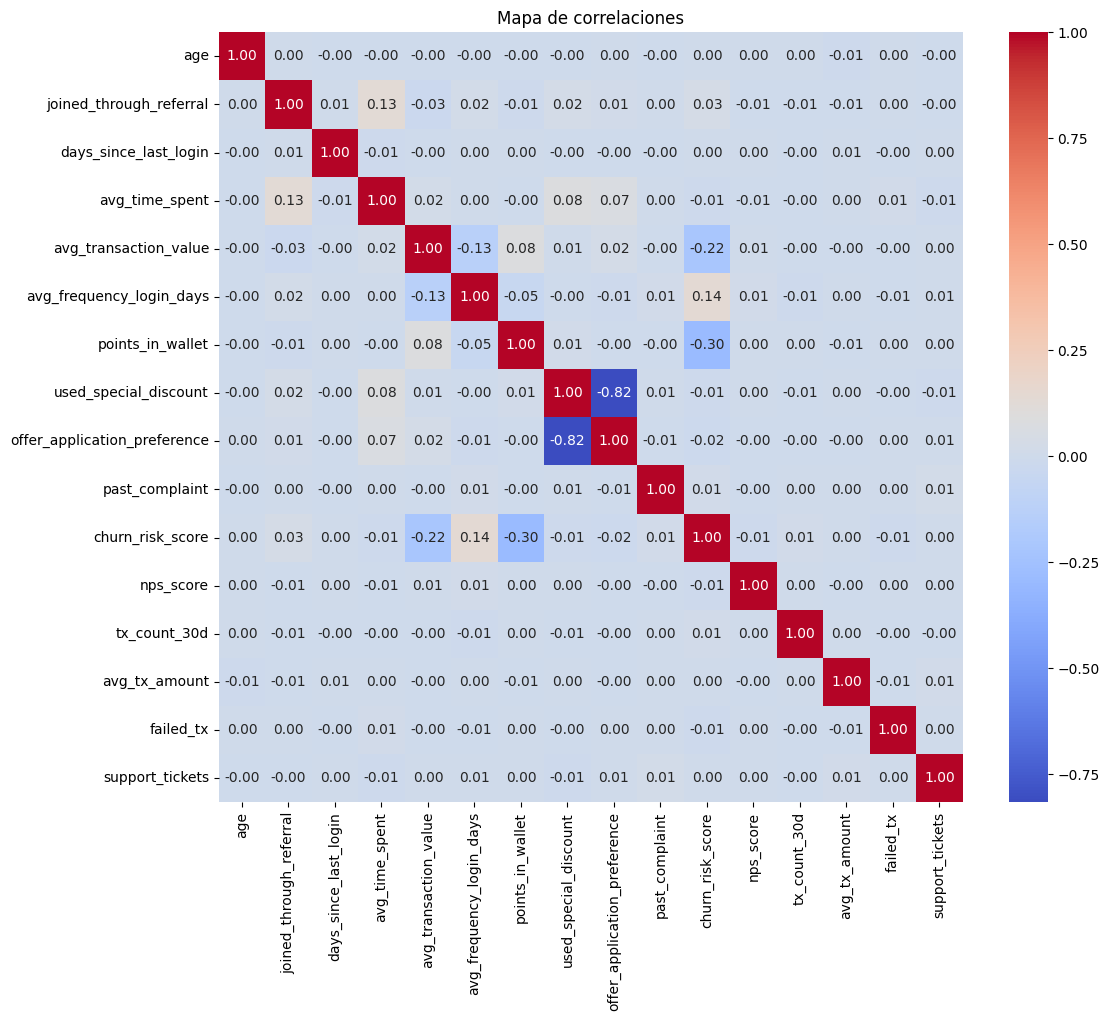

In [ ]:
#Mapa de calor, variables numéricas
corr = df_customer.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Mapa de correlaciones')
plt.show()

###Método Spearman (No lineal)

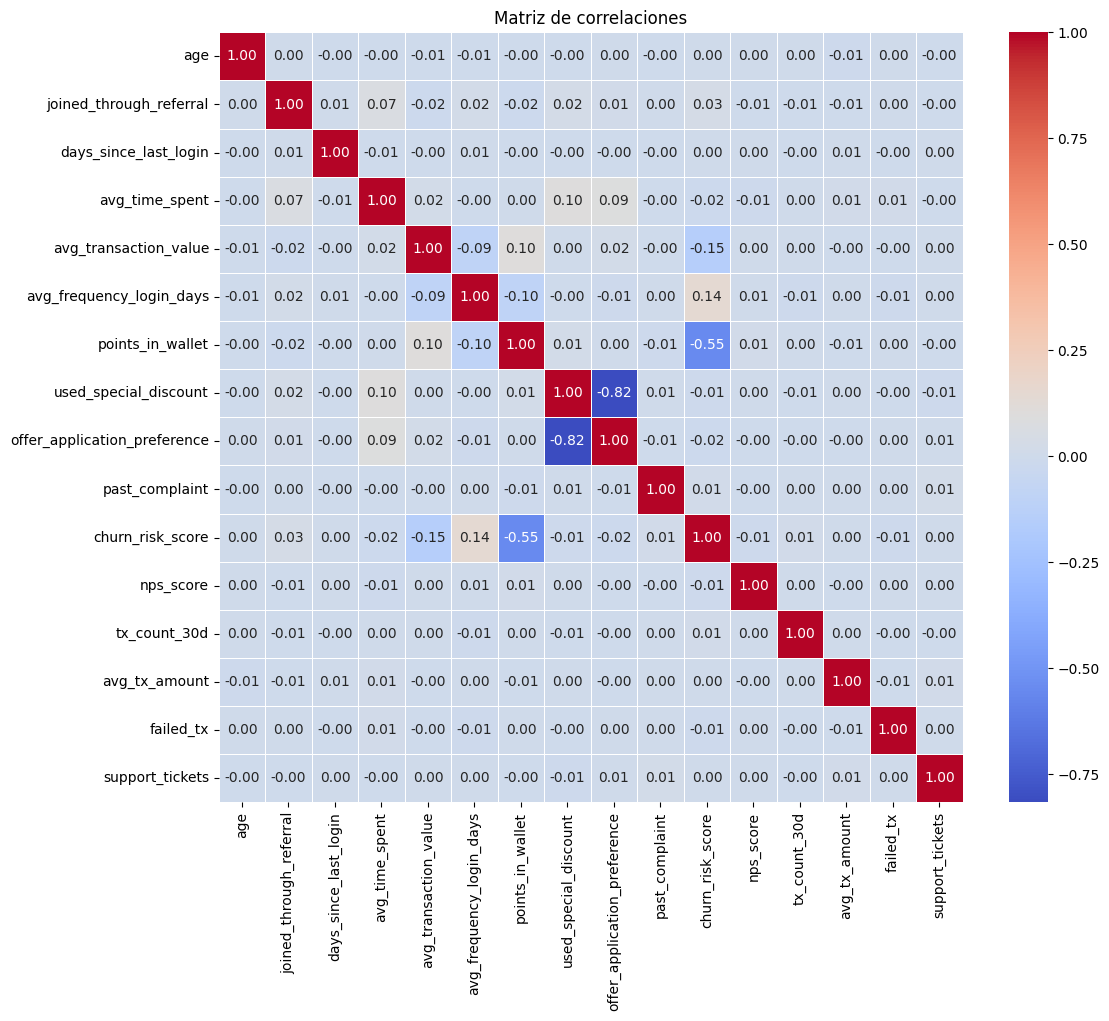

In [ ]:
#Mapa de calor numéricas, con Spearman
corr = df_customer.corr(numeric_only=True, method='spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlaciones')
plt.show()

**Observaciones**:
- A más puntos (points_in_wallet), menor riesgo de churn.


###Prueba de Chi2
Utilizaremos la prueba de chi para analizar si existe una relación significativa entre las variables categóricas. Ya que, el estadístico Chi-cuadrado es una prueba de hipótesis que mide la discrepancia entre las **frecuencias observadas** en una muestra y las **frecuencias esperadas** bajo una hipótesis nula específica.

- **H0: es la Hipótesis Nula.**(Frecuencias observadas)
Se plantea que las variables son independientes.
- **H1: Hipótesis Alternativa.** (Frecuencias esperadas)
Las variables son dependientes (o están asociadas)

- La V de Cramer es una medida de la fuerza de asociación entre dos variables categóricas.Deriva de Chi-cuadrado, pero está ajustado para el tamaño de la muestra y el número de categorías, lo que permite cuantificar la intensidad de la relación. Sus valores varían de 0 a 1 (0: Indica que no hay asociación entre las variables y 1: Indica una asociación perfecta).
Se plantea la hipótesis de trabajo (HT, "La hipótesis de utilidad"). La asociación entre las variables es lo suficientemente fuerte ($V > 0.10$ o $V > 0.30$) para ser utilizada en modelos predictivos.

- El p-valor es el resultado de la prueba de Chi-cuadrado. Es el número que se obtiene de esa prueba estadística para tomar la decisión de rechazar o no la hipótesis nula de independencia. El nivel de significancia comúnmente establecido en un 5% (0,05). Un resultado se considera estadísticamente significativo si el valor p es igual o inferior al nivel de significación, lo que permite rechazar la hipótesis nula.
Esta condición se suele expresar como p≤0,05.

Se buscará probar H1 con el p-valor y luego validar el resultado con Ht de Cramer's


In [ ]:
#Función para calcular Cramér's V
def cramers_v(x, y):
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    tabla = pd.crosstab(df['x'], df['y'])
    n = tabla.sum().sum()
    r, k = tabla.shape
    if r < 2 or k < 2 or n <= 1:
        return np.nan

    chi2 = chi2_contingency(tabla, correction=False)[0]
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2corr / denom)

#Función para interpretar fuerza
def interpretar_v(v):
    if pd.isna(v):
        return "Sin datos"
    elif v < 0.10:
        return "Muy débil o nula"
    elif v < 0.30:
        return "Débil"
    elif v < 0.50:
        return "Moderada"
    else:
        return "Fuerte"

In [ ]:
#Análisis unidireccional contra el target (Churn VS columnas categóricas)

# Seleccionar columnas tipo object o category y ponerlas en una lista
cat_cols = df_customer.select_dtypes(include=['object', 'category']).columns.tolist()

# Excluir la columna 'security_no'
cat_cols.remove('security_no')

# Definir la variable target fuera del bucle
col_target = 'churn_risk_score'

# Crear una lista para guardar resultados
resultados_target = []

"""
Se crea un bucle simple que compara cada columna categórica (feature)
con la variable objetivo (col_target).
"""
for feature in cat_cols:
    # Definimos las variables para el análisis
    x = df_customer[feature]
    y = df_customer[col_target]

    # 1. Crear la tabla de contingencia
    tabla = pd.crosstab(x, y)

    # 2. Aplicar la prueba Chi-cuadrado y obtener el p-valor
    chi2, p, dof, expected = chi2_contingency(tabla, correction=False)

    # 3. Calcular Cramér’s V
    v = cramers_v(x, y)

    # 4. Interpretar la fuerza
    interpretacion = interpretar_v(v)

    resultados_target.append({
        'Feature': feature,
        'Target': col_target,
        'Chi-cuadrado': chi2,
        'p-valor': round(p, 4),
        'Significativo': 'Sí' if p < 0.05 else 'No',
        "Cramér's V": round(v, 4) if not pd.isna(v) else np.nan,
        'Fuerza de relación': interpretacion
    })

# Crear DataFrame con resultados
tabla_ranking_categorica = pd.DataFrame(resultados_target)

# Ordenamos por la fuerza de asociación (Cramér's V) para obtener el ranking
tabla_ranking_categorica = tabla_ranking_categorica.sort_values(by="Cramér's V", ascending=False)

# Mostrar los primeros 20 registros de la tabla de chi
display(tabla_ranking_categorica.shape,
        tabla_ranking_categorica.head(28))

(8, 7)

,Feature,Target,Chi-cuadrado,p-valor,Significativo,Cramér's V,Fuerza de relación
2,membership_category,churn_risk_score,19585.479285,0.0000,Sí,0.7867,Fuerte
7,feedback,churn_risk_score,6638.047632,0.0000,Sí,0.4578,Moderada
3,preferred_offer_types,churn_risk_score,57.394179,0.0000,Sí,0.0418,Muy débil o nula
1,region_category,churn_risk_score,17.410487,0.0002,Sí,0.0221,Muy débil o nula
4,medium_of_operation,churn_risk_score,14.483207,0.0007,Sí,0.0199,Muy débil o nula
6,complaint_status,churn_risk_score,5.353935,0.2529,No,0.0065,Muy débil o nula
5,internet_option,churn_risk_score,2.278266,0.3201,No,0.0030,Muy débil o nula
0,gender,churn_risk_score,0.352914,0.5525,No,0.0000,Muy débil o nula


In [ ]:
#Para visualizar posteriormente los heatmaps

#Selecciono la lista de columnas
cat_cols = df_customer.select_dtypes(include=['object', 'category']).columns.tolist()

# Excluir columnas no relevantes
if 'security_no' in cat_cols:
    cat_cols.remove('security_no')

# Definir la variable target
col_target = 'churn_risk_score'

# Crear matrices vacías (una fila por cada columna categórica)
matriz_v = pd.DataFrame(np.nan, index=cat_cols, columns=['Cramér\'s V'])
matriz_p = pd.DataFrame(np.nan, index=cat_cols, columns=['p-valor'])

# Calcular Cramér’s V y p-valor entre cada variable categórica y el target
for col in cat_cols:
    tabla = pd.crosstab(df_customer[col], df_customer[col_target])
    chi2, p, dof, expected = chi2_contingency(tabla, correction=False)
    v = cramers_v(df_customer[col], df_customer[col_target])

    matriz_v.loc[col, "Cramér's V"] = v
    matriz_p.loc[col, "p-valor"] = p


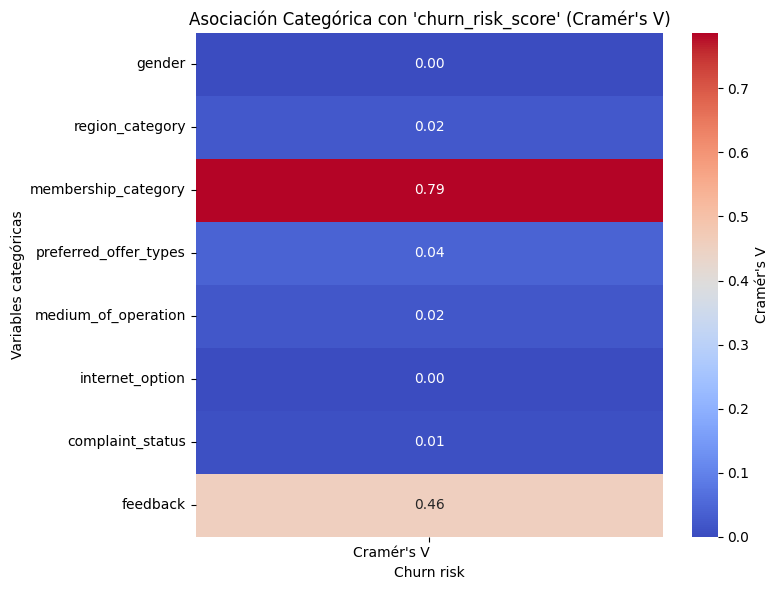

In [ ]:
#Heatmap de Cramers'V
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_v, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': "Cramér's V"})
plt.title("Asociación Categórica con 'churn_risk_score' (Cramér's V)")
plt.xlabel("Churn risk")
plt.ylabel("Variables categóricas")
plt.xticks(rotation=0, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

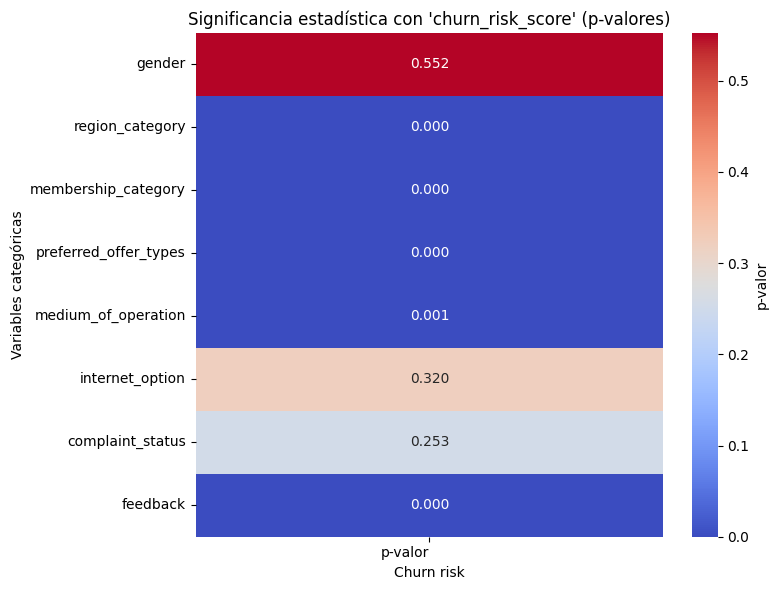

In [ ]:
#Heatmap p-valor
plt.figure(figsize=(8,6))
sns.heatmap(matriz_p, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={'label': "p-valor"})
plt.title("Significancia estadística con 'churn_risk_score' (p-valores)")
plt.xlabel("Churn risk")
plt.ylabel("Variables categóricas")
plt.xticks(rotation=0, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()